In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"D:\Salary_dataset.csv.xls")
print(df)

    Unnamed: 0  YearsExperience    Salary
0            0              1.2   39344.0
1            1              1.4   46206.0
2            2              1.6   37732.0
3            3              2.1   43526.0
4            4              2.3   39892.0
5            5              3.0   56643.0
6            6              3.1   60151.0
7            7              3.3   54446.0
8            8              3.3   64446.0
9            9              3.8   57190.0
10          10              4.0   63219.0
11          11              4.1   55795.0
12          12              4.1   56958.0
13          13              4.2   57082.0
14          14              4.6   61112.0
15          15              5.0   67939.0
16          16              5.2   66030.0
17          17              5.4   83089.0
18          18              6.0   81364.0
19          19              6.1   93941.0
20          20              6.9   91739.0
21          21              7.2   98274.0
22          22              8.0  1

In [3]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [6]:
df.shape

(30, 3)

In [7]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

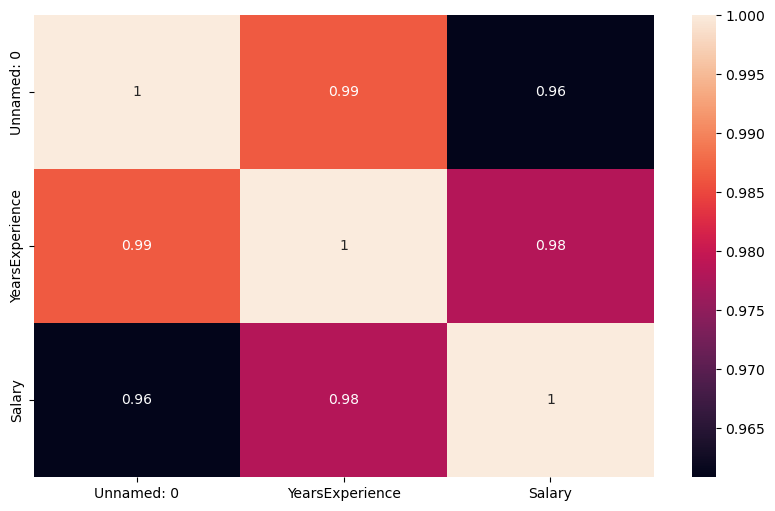

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [10]:
df = df.drop(columns=["Unnamed: 0"])

In [11]:
def categorize_experience(years):
    if years < 3:
        return "Junior"
    elif years < 7:
        return "Mid-Level"
    else:
        return "Senior"

df["Experience_Level"] = df["YearsExperience"].apply(categorize_experience)

In [12]:
df.head()

,YearsExperience,Salary,Experience_Level
0,1.2,39344.0,Junior
1,1.4,46206.0,Junior
2,1.6,37732.0,Junior
3,2.1,43526.0,Junior
4,2.3,39892.0,Junior


In [14]:
summary = df.groupby("Experience_Level")["Salary"].mean()
print("Average Salary by Experience Level:")
print(summary)

df.to_csv("processed_salary_data.csv", index=False)
print("\nTransformation complete! File saved as processed_salary_data.csv")

Average Salary by Experience Level:
Experience_Level
Junior        41340.0
Mid-Level     66946.5
Senior       111364.0
Name: Salary, dtype: float64

Transformation complete! File saved as processed_salary_data.csv


In [15]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
Y_predict=model.predict(X_test)

In [22]:
print(Y_predict)

[115791.21011287  71499.27809463 102597.86866063  75268.80422384
  55478.79204548  60190.69970699]


In [26]:
comparision=pd.DataFrame({
    "Actual":y_test,
    "Predicted":Y_predict})

In [27]:
comparision

,Actual,Predicted
27,112636.0,115791.210113
15,67939.0,71499.278095
23,113813.0,102597.868661
17,83089.0,75268.804224
8,64446.0,55478.792045
9,57190.0,60190.699707


In [29]:
print(model.score(X_test,y_test))

0.9024461774180498
